# 6. Quantitative analysis

Once the depth rasters are on disk, EuroFlood turns them into numbers — per-event and
aggregated — so you can rank events, estimate exposure, and compare flooding across years, all
without leaving Python.

> This tutorial downloads real rasters, so it needs network access.

In [1]:
from pathlib import Path

import euroflood as ef

ef.settings.output_dir = Path("out")

# Download the depth rasters for the six largest events — enough to compare, and quick.
# (Drop the `.head(6)` to analyse every event; a download progress bar shows while it runs.)
cat = ef.floods("Zutphen, Netherlands", shape="bbox")  # bbox ROI (tutorial 02)
dl = cat.sort_values("area_km2", ascending=False).head(6).download()

In [2]:
dl

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry,path
2,historic,1811386473,2018-01-22,2018,2018-03-05,358,WD_MERGE_2018-01-22---2018-03-05_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,29.103,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2018-01-22_id1811386473_8277ba1c.tif
19,historic,3623893553,2018-01-01,2018,2018-01-29,351,WD_MERGE_2018-01-01---2018-01-29_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,9.277,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2018-01-01_id3623893553_8277ba1c.tif
20,historic,3211422323,2023-12-11,2023,2024-01-01,358,WD_MERGE_2023-12-11---2024-01-01_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,9.234,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2023-12-11_id3211422323_8277ba1c.tif
28,historic,3351340227,2020-02-24,2020,2020-04-06,380,WD_MERGE_2020-02-24---2020-04-06_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,9.097,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2020-02-24_id3351340227_8277ba1c.tif
11,historic,3215720203,2023-10-09,2023,2023-11-27,346,WD_MERGE_2023-10-09---2023-11-27_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,8.516,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2023-10-09_id3215720203_8277ba1c.tif
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,8.474,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2024-01-01_id2217388040_8277ba1c.tif


## Per-event statistics

`.stats()` returns one row per downloaded event with, for each: the number of wet pixels, the
**max / mean / p95 depth** (metres), the **flooded area** (km²), and the **water volume**
(m³ and million m³). EFAS centimetres are scaled to metres automatically.

In [3]:
stats = dl.stats()
stats

,event_id,date,wet_pixels,max_depth_m,mean_depth_m,p95_depth_m,flooded_area_km2,volume_m3,volume_Mm3
0,1811386473,2018-01-22,56816,6.78,0.509,1.730,22.7264,11561892.0,11.5619
1,3623893553,2018-01-01,18384,6.38,0.933,2.308,7.3536,6859016.0,6.8590
2,3211422323,2023-12-11,18279,4.27,0.730,1.980,7.3116,5336436.0,5.3364
3,3351340227,2020-02-24,18024,5.58,0.880,2.150,7.2096,6343796.0,6.3438
4,3215720203,2023-10-09,16145,5.57,0.794,2.240,6.4580,5125944.0,5.1259
5,2217388040,2024-01-01,14846,2.24,0.181,0.540,5.9384,1072996.0,1.0730


It is an ordinary DataFrame — rank the events by how much water they moved:

In [4]:
stats.sort_values("volume_Mm3", ascending=False)[
    ["event_id", "date", "max_depth_m", "flooded_area_km2", "volume_Mm3"]
]

,event_id,date,max_depth_m,flooded_area_km2,volume_Mm3
0,1811386473,2018-01-22,6.78,22.7264,11.5619
1,3623893553,2018-01-01,6.38,7.3536,6.8590
3,3351340227,2020-02-24,5.58,7.2096,6.3438
2,3211422323,2023-12-11,4.27,7.3116,5.3364
4,3215720203,2023-10-09,5.57,6.4580,5.1259
5,2217388040,2024-01-01,2.24,5.9384,1.0730


A quick bar chart of the peak depth per event:

Text(0, 0.5, 'max depth (m)')

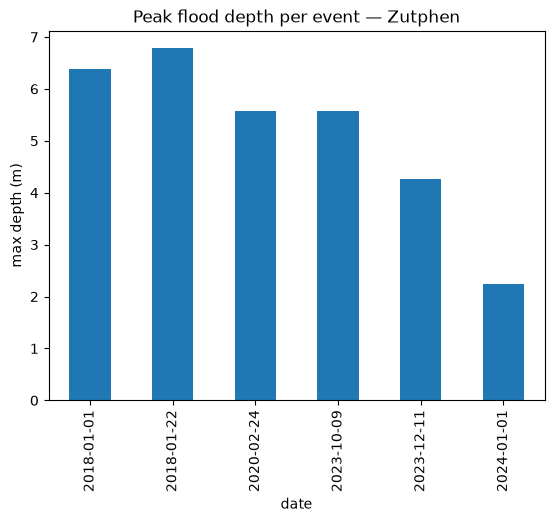

In [5]:
ax = stats.sort_values("date").plot.bar(
    x="date",
    y="max_depth_m",
    legend=False,
    title="Peak flood depth per event — Zutphen",
)
ax.set_ylabel("max depth (m)")

## The aggregate envelope

`.summary()` combines every downloaded raster into a per-pixel **maximum** composite (so
overlapping floods are counted once) and returns the same measures plus `n_events` — the
"worst case seen" across the whole record:

In [6]:
dl.summary()

{'wet_pixels': 38920,
 'max_depth_m': 6.33,
 'mean_depth_m': 0.523,
 'p95_depth_m': 1.74,
 'flooded_area_km2': 23.52,
 'volume_m3': 12291067.2,
 'volume_Mm3': 12.2911,
 'n_events': 6}

## The depth distribution of one event

Read a single raster and look at where the water actually was — most flooded cells are shallow,
with a thin tail of deep water:

41,525 wet pixels · median 0.25 m · max 6.34 m


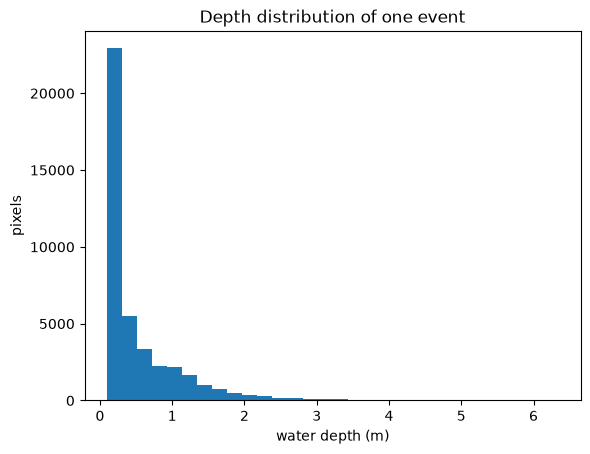

In [7]:
import matplotlib.pyplot as plt
import numpy as np

depth = dl.depths()[0]
array, *_ = depth.read()
wet_m = array[array > 0] * 0.01  # centimetres -> metres

_fig, ax = plt.subplots()
ax.hist(wet_m, bins=30)
ax.set(
    xlabel="water depth (m)", ylabel="pixels", title="Depth distribution of one event"
)
print(
    f"{wet_m.size:,} wet pixels · median {np.median(wet_m):.2f} m · max {wet_m.max():.2f} m"
)